## Setup and Data Overview
We are working with two chest X-ray datasets for pneumonia detection. The first is the Chest X-Ray Images dataset containing 5,863 labeled JPEG images. The second is the RSNA Pneumonia Detection Challenge dataset with 29,700+ DICOM images and metadata. Here we load the required libraries and verify the folder structure of the Chest X-Ray dataset by counting images in each split.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Update these paths to where you downloaded the data on your machine
chest_xray_path = "chest_xray"  # the folder with train/test/val
rsna_path = "rsna"  # the folder with CSVs and image folders

# Check chest x-ray folder structure
for split in ['train', 'test', 'val']:
    normal = len(os.listdir(os.path.join(chest_xray_path, split, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(chest_xray_path, split, 'PNEUMONIA')))
    print(f"{split}: Normal={normal}, Pneumonia={pneumonia}, Total={normal+pneumonia}")

train: Normal=1341, Pneumonia=3875, Total=5216
test: Normal=234, Pneumonia=390, Total=624
val: Normal=8, Pneumonia=8, Total=16


## Chest X-Ray: Class Distribution
Understanding class distribution is critical before training a model. If one class significantly outnumbers the other, the model may become biased toward the majority class, a problem known as class imbalance. Here we visualize how many normal vs pneumonia images exist in each split.

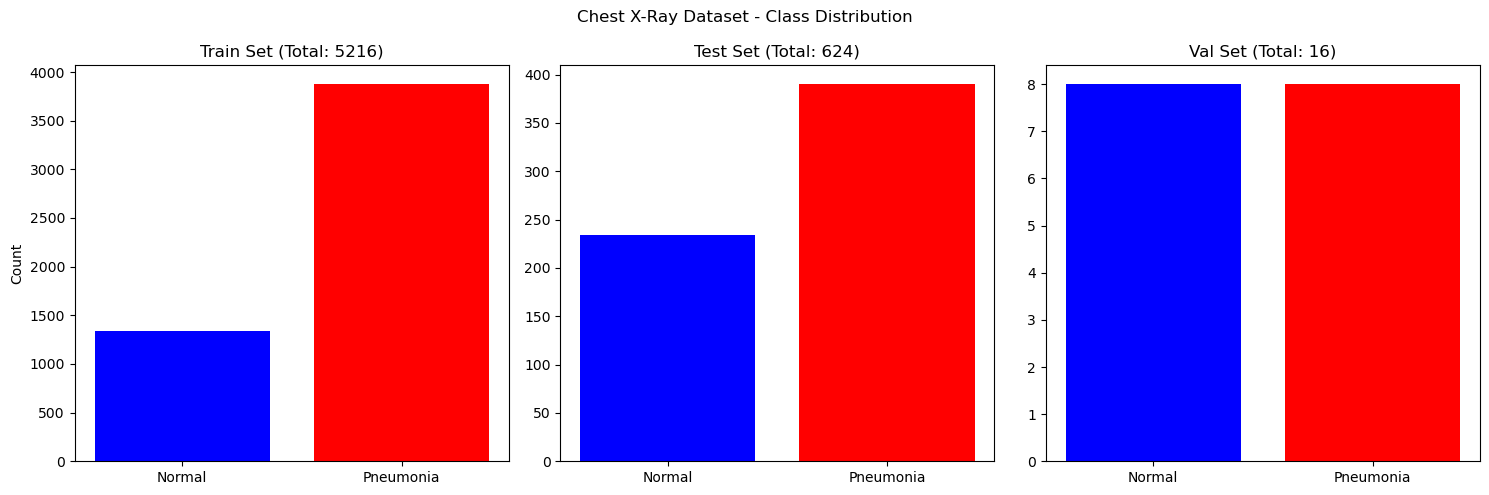


Train set imbalance ratio: 2.89 pneumonia per normal


In [2]:
train_normal = len(os.listdir(os.path.join(chest_xray_path, 'train', 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(chest_xray_path, 'train', 'PNEUMONIA')))
test_normal = len(os.listdir(os.path.join(chest_xray_path, 'test', 'NORMAL')))
test_pneumonia = len(os.listdir(os.path.join(chest_xray_path, 'test', 'PNEUMONIA')))
val_normal = len(os.listdir(os.path.join(chest_xray_path, 'val', 'NORMAL')))
val_pneumonia = len(os.listdir(os.path.join(chest_xray_path, 'val', 'PNEUMONIA')))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Normal', 'Pneumonia'], [train_normal, train_pneumonia], color=['blue', 'red'])
axes[0].set_title(f'Train Set (Total: {train_normal + train_pneumonia})')
axes[0].set_ylabel('Count')

axes[1].bar(['Normal', 'Pneumonia'], [test_normal, test_pneumonia], color=['blue', 'red'])
axes[1].set_title(f'Test Set (Total: {test_normal + test_pneumonia})')

axes[2].bar(['Normal', 'Pneumonia'], [val_normal, val_pneumonia], color=['blue', 'red'])
axes[2].set_title(f'Val Set (Total: {val_normal + val_pneumonia})')

plt.suptitle('Chest X-Ray Dataset - Class Distribution')
plt.tight_layout()
plt.show()

# Print class imbalance ratio
print(f"\nTrain set imbalance ratio: {train_pneumonia/train_normal:.2f} pneumonia per normal")

## Chest X-Ray: Sample Images
Before building a model, it's important to visually inspect the data. This helps us understand what the images look like and whether there are visible differences between normal and pneumonia X-rays. Normal lungs appear clear while pneumonia shows cloudy white patches caused by fluid in the lungs.

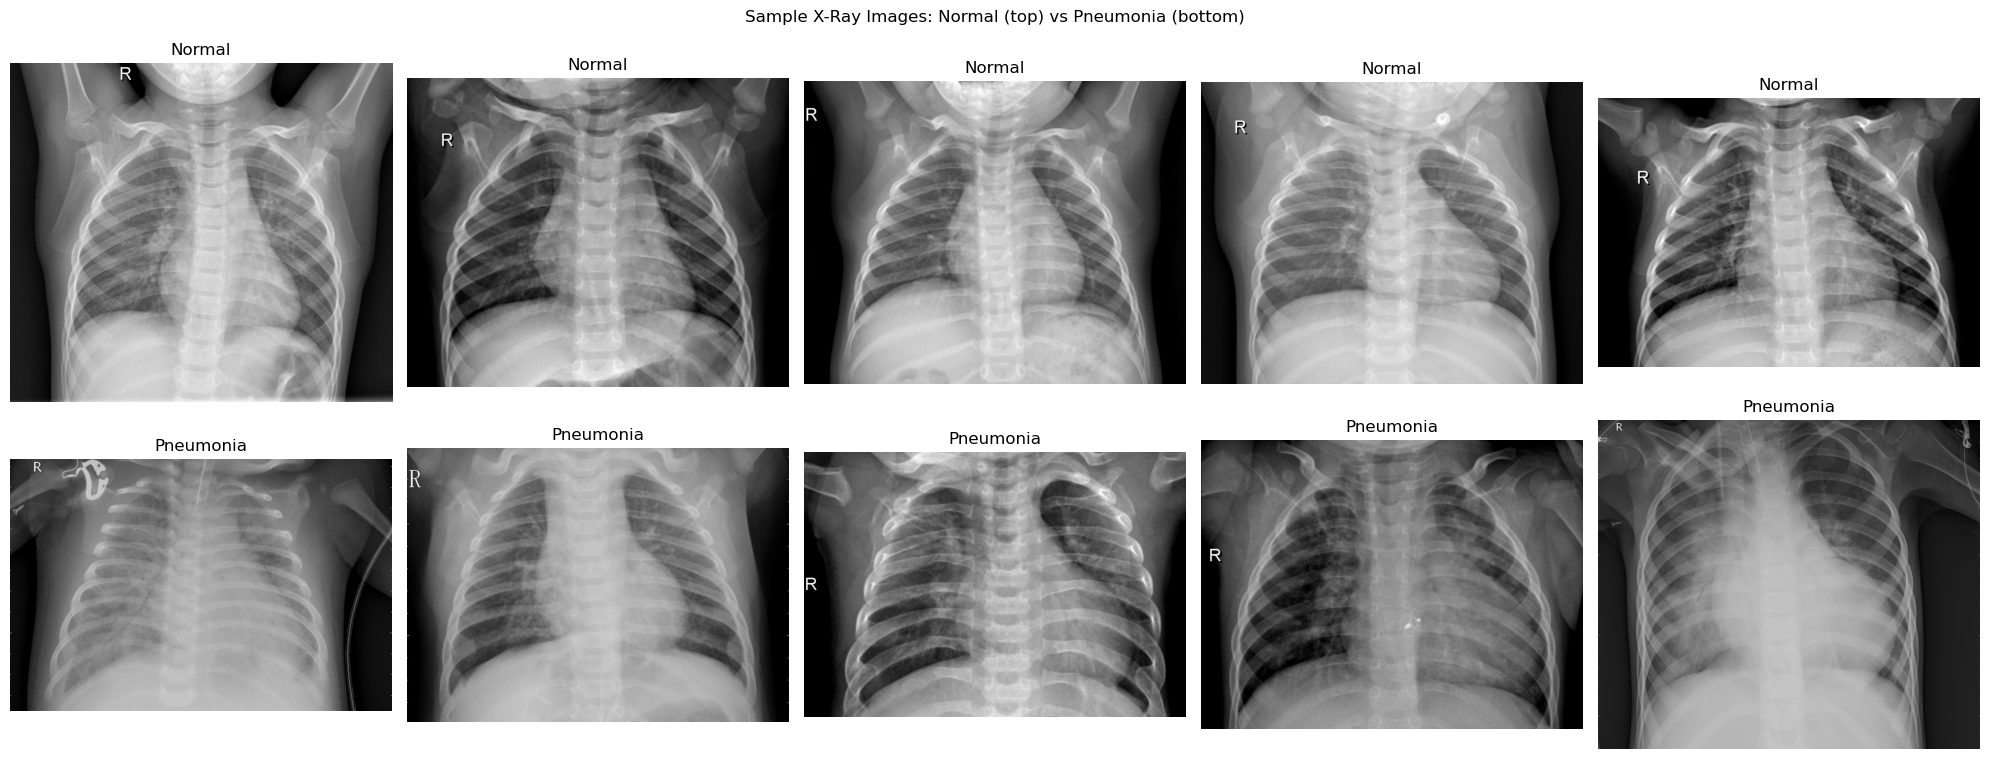

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

normal_files = os.listdir(os.path.join(chest_xray_path, 'train', 'NORMAL'))
pneumonia_files = os.listdir(os.path.join(chest_xray_path, 'train', 'PNEUMONIA'))

for i in range(5):
    img = Image.open(os.path.join(chest_xray_path, 'train', 'NORMAL', normal_files[i]))
    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title('Normal')
    axes[0][i].axis('off')

for i in range(5):
    img = Image.open(os.path.join(chest_xray_path, 'train', 'PNEUMONIA', pneumonia_files[i]))
    axes[1][i].imshow(img, cmap='gray')
    axes[1][i].set_title('Pneumonia')
    axes[1][i].axis('off')

plt.suptitle('Sample X-Ray Images: Normal (top) vs Pneumonia (bottom)')
plt.tight_layout()
plt.show()

## Chest X-Ray: Image Size Distribution
CNNs require all input images to be the same size. Here we check whether the images in our dataset have consistent dimensions or if they vary. If sizes are inconsistent, we will need to resize all images to a standard size (e.g., 224x224) during preprocessing.

Width  — min: 502, max: 2538, mean: 1442
Height — min: 307, max: 2066, mean: 1086


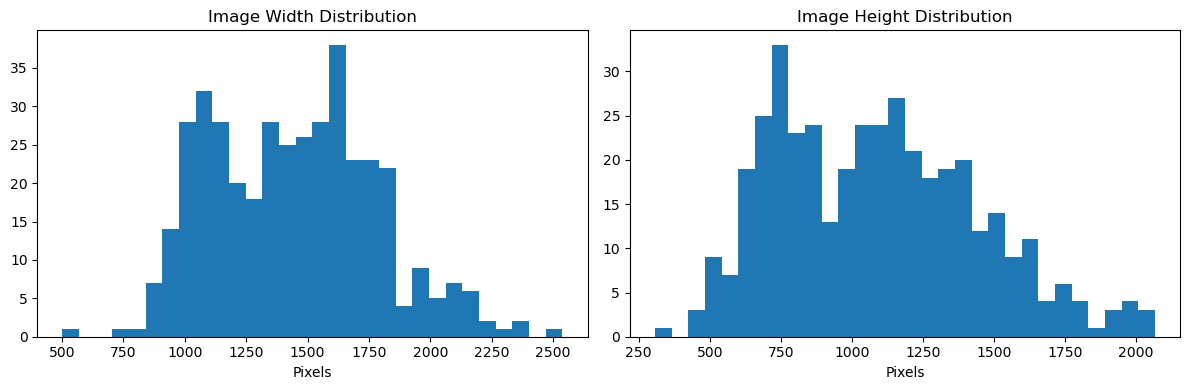

In [4]:
widths = []
heights = []
labels = []

for label, folder in [('Normal', 'NORMAL'), ('Pneumonia', 'PNEUMONIA')]:
    files = os.listdir(os.path.join(chest_xray_path, 'train', folder))
    for f in files[:200]:  # sample 200 from each to save time
        img = Image.open(os.path.join(chest_xray_path, 'train', folder, f))
        widths.append(img.size[0])
        heights.append(img.size[1])
        labels.append(label)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Pixels')
axes[1].hist(heights, bins=30)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Pixels')
plt.tight_layout()
plt.show()

## Chest X-Ray: Pixel Intensity Comparison
Pixel intensity distributions can reveal patterns between classes. In X-rays, pneumonia appears as white cloudy areas due to fluid in the lungs, which shifts pixel values toward mid range intensities. Normal lungs have more clear/bright areas. If the distributions differ between classes, it means there is a learnable visual pattern for the CNN.

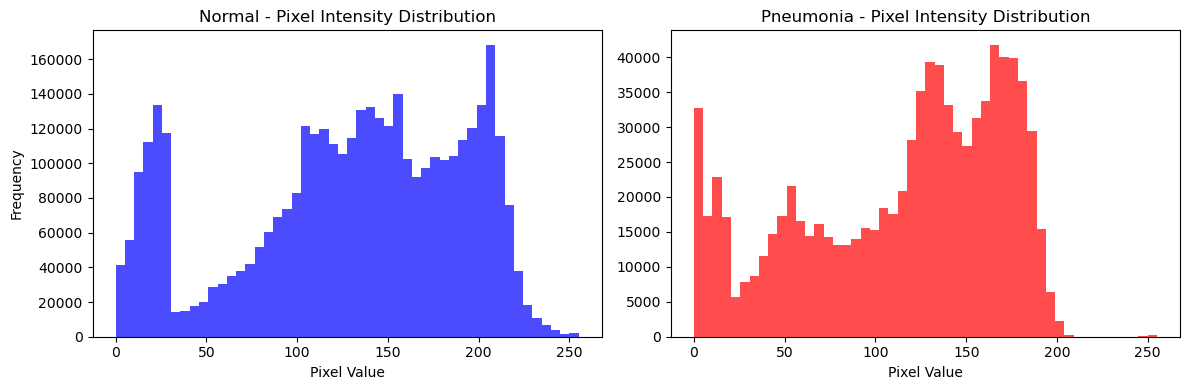

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Normal image pixel distribution
normal_img = np.array(Image.open(os.path.join(chest_xray_path, 'train', 'NORMAL', normal_files[0])).convert('L'))
axes[0].hist(normal_img.flatten(), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Normal - Pixel Intensity Distribution')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

# Pneumonia image pixel distribution
pneumonia_img = np.array(Image.open(os.path.join(chest_xray_path, 'train', 'PNEUMONIA', pneumonia_files[0])).convert('L'))
axes[1].hist(pneumonia_img.flatten(), bins=50, color='red', alpha=0.7)
axes[1].set_title('Pneumonia - Pixel Intensity Distribution')
axes[1].set_xlabel('Pixel Value')

plt.tight_layout()
plt.show()

## RSNA Dataset: Inspect Labels and Metadata
The RSNA dataset provides more detailed information than the Chest X-Ray dataset. The labels file contains bounding box coordinates (x, y, width, height) for pneumonia locations and a binary target. The detailed class info file breaks patients into three categories: Normal, No Lung Opacity / Not Normal (abnormal but not pneumonia), and Lung Opacity (pneumonia). This three-class distinction is important because some patients have lung abnormalities that are not pneumonia, making classification more challenging.

In [8]:
# Load RSNA labels
rsna_labels = pd.read_csv(os.path.join(rsna_path, 'stage_2_train_labels.csv'))
rsna_details = pd.read_csv(os.path.join(rsna_path, 'stage_2_detailed_class_info.csv'))

print("Labels shape:", rsna_labels.shape)
print("Details shape:", rsna_details.shape)

display(rsna_labels.head())
display(rsna_details.head())

Labels shape: (30227, 6)
Details shape: (30227, 2)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


## RSNA Dataset: Class Distribution
Here we visualize both the binary target distribution (pneumonia vs not) and the detailed three class breakdown. Understanding the balance between classes helps us determine if resampling or weighted loss functions will be needed during training to prevent the model from being biased toward the majority class.

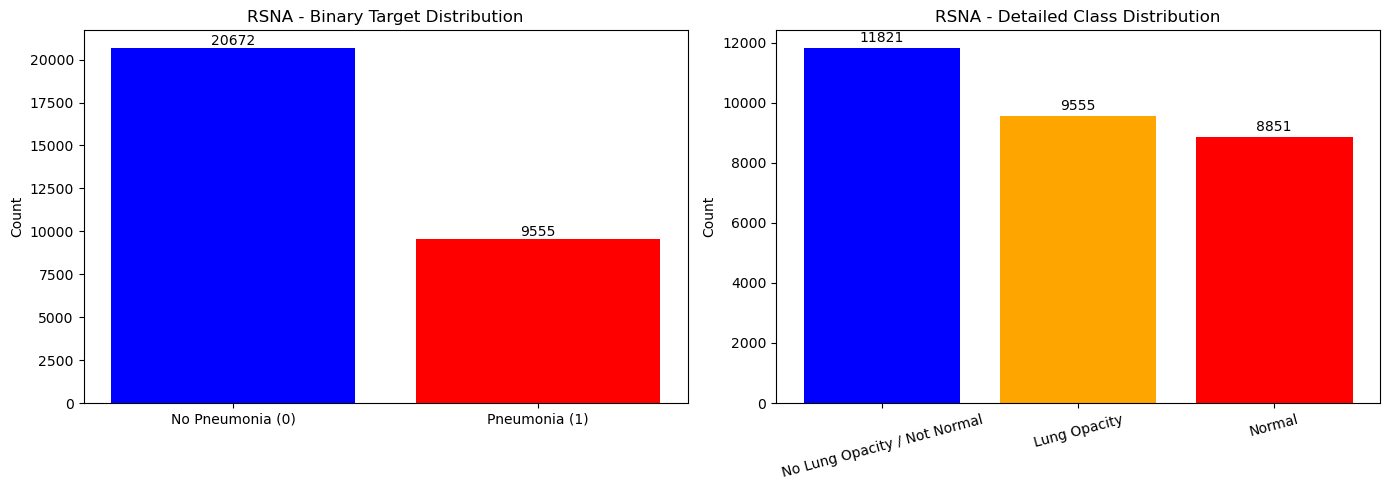


Total images: 30227
Target 0: 20672 (68.4%)
Target 1: 9555 (31.6%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target distribution
target_counts = rsna_labels['Target'].value_counts()
axes[0].bar(['No Pneumonia (0)', 'Pneumonia (1)'], target_counts.values, color=['blue', 'red'])
axes[0].set_title('RSNA - Binary Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center')

# Detailed class distribution
class_counts = rsna_details['class'].value_counts()
axes[1].bar(class_counts.index, class_counts.values, color=['blue', 'orange', 'red'])
axes[1].set_title('RSNA - Detailed Class Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center')

plt.tight_layout()
plt.show()

# Print percentages
total = len(rsna_labels)
print(f"\nTotal images: {total}")
for target, count in target_counts.items():
    print(f"Target {target}: {count} ({count/total*100:.1f}%)")

## RSNA Dataset: Bounding Box Analysis
Some pneumonia patients have multiple areas of infection, resulting in multiple bounding boxes per image. This analysis shows how many bounding boxes each pneumonia patient has. This is relevant because patients with multiple infection areas may represent more severe cases and could be harder for the model to detect accurately.

Pneumonia cases with bounding boxes: 9555
Unique patients with pneumonia: 6012

Bounding boxes per patient:
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64


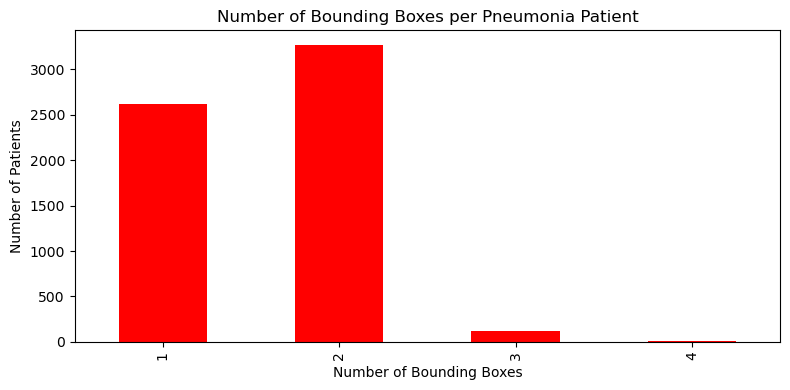

In [10]:
# Look at bounding box info for pneumonia cases
pneumonia_cases = rsna_labels[rsna_labels['Target'] == 1]
print(f"Pneumonia cases with bounding boxes: {len(pneumonia_cases)}")
print(f"Unique patients with pneumonia: {pneumonia_cases['patientId'].nunique()}")

# Some patients have multiple bounding boxes (multiple areas of infection)
bbox_counts = pneumonia_cases.groupby('patientId').size()
print(f"\nBounding boxes per patient:")
print(bbox_counts.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
bbox_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='red')
ax.set_title('Number of Bounding Boxes per Pneumonia Patient')
ax.set_xlabel('Number of Bounding Boxes')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.show()

## RSNA Dataset: Sample DICOM Images
The RSNA images are in DICOM format, which is the standard medical imaging format. Unlike JPEG images, DICOM files contain additional metadata like patient information and imaging parameters. Here we display sample normal and pneumonia images from the RSNA dataset to visually compare them with the Chest X-Ray dataset images.

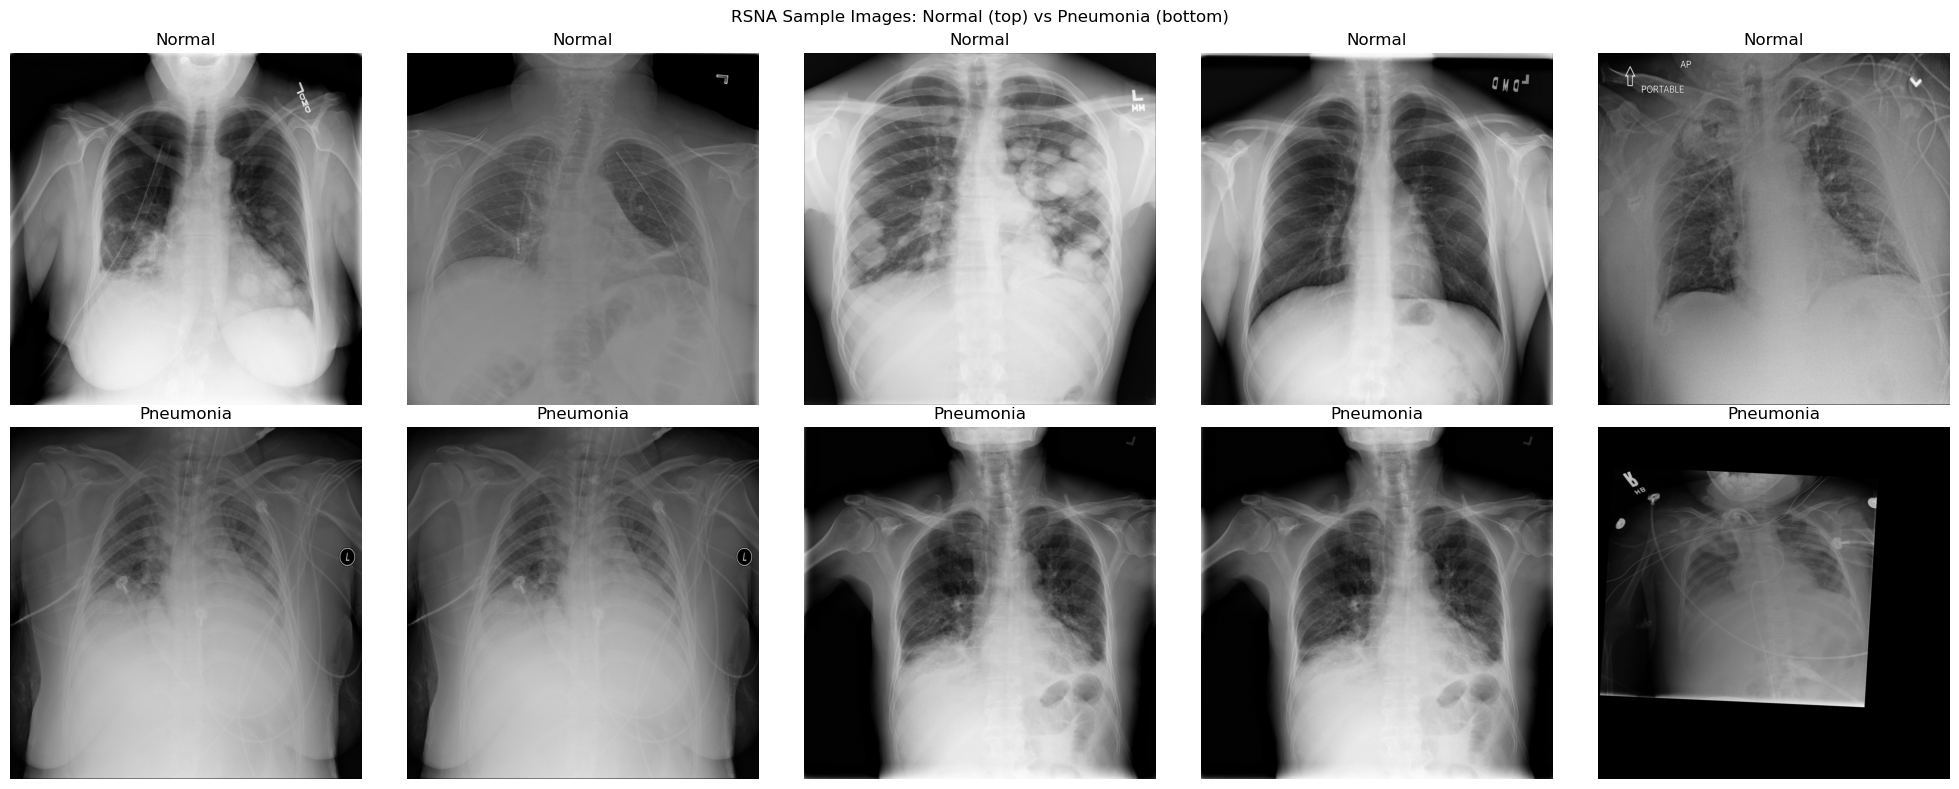

In [11]:
import pydicom

rsna_train_path = os.path.join(rsna_path, 'stage_2_train_images')

# Get sample patient IDs
normal_ids = rsna_labels[rsna_labels['Target'] == 0]['patientId'].head(5).tolist()
pneumonia_ids = rsna_labels[rsna_labels['Target'] == 1]['patientId'].head(5).tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, pid in enumerate(normal_ids):
    dcm = pydicom.dcmread(os.path.join(rsna_train_path, f'{pid}.dcm'))
    axes[0][i].imshow(dcm.pixel_array, cmap='gray')
    axes[0][i].set_title('Normal')
    axes[0][i].axis('off')

for i, pid in enumerate(pneumonia_ids):
    dcm = pydicom.dcmread(os.path.join(rsna_train_path, f'{pid}.dcm'))
    axes[1][i].imshow(dcm.pixel_array, cmap='gray')
    axes[1][i].set_title('Pneumonia')
    axes[1][i].axis('off')

plt.suptitle('RSNA Sample Images: Normal (top) vs Pneumonia (bottom)')
plt.tight_layout()
plt.show()

## EDA Summary
This summary consolidates all findings from our exploratory data analysis across both datasets. Key observations include class imbalance, image size variability, pixel intensity differences between classes, and the detailed class breakdown in the RSNA dataset. These findings will guide our preprocessing and model training decisions.

In [12]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("\n--- Chest X-Ray Dataset ---")
print(f"Train: {train_normal} normal, {train_pneumonia} pneumonia")
print(f"Test:  {test_normal} normal, {test_pneumonia} pneumonia")
print(f"Val:   {val_normal} normal, {val_pneumonia} pneumonia")
print(f"Total: {train_normal+test_normal+val_normal} normal, {train_pneumonia+test_pneumonia+val_pneumonia} pneumonia")
print(f"Class imbalance: {'Yes' if train_pneumonia/train_normal > 1.5 else 'No'}")

print("\n--- RSNA Dataset ---")
print(f"Total images: {len(rsna_labels)}")
print(f"Pneumonia: {target_counts.get(1, 0)} ({target_counts.get(1,0)/total*100:.1f}%)")
print(f"Normal: {target_counts.get(0, 0)} ({target_counts.get(0,0)/total*100:.1f}%)")

print("\n--- Key Observations ---")
print(f"Image sizes vary: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
print("Images will need resizing to a standard size (e.g., 224x224) for CNN")
print("Class imbalance exists — consider resampling or weighted loss")
print("RSNA images are DICOM format, Chest X-Ray images are JPEG/PNG")

EDA SUMMARY

--- Chest X-Ray Dataset ---
Train: 1341 normal, 3875 pneumonia
Test:  234 normal, 390 pneumonia
Val:   8 normal, 8 pneumonia
Total: 1583 normal, 4273 pneumonia
Class imbalance: Yes

--- RSNA Dataset ---
Total images: 30227
Pneumonia: 9555 (31.6%)
Normal: 20672 (68.4%)

--- Key Observations ---
Image sizes vary: 502x307 to 2538x2066
Images will need resizing to a standard size (e.g., 224x224) for CNN
Class imbalance exists — consider resampling or weighted loss
RSNA images are DICOM format, Chest X-Ray images are JPEG/PNG
